# Credit Card Fraud Detection on Highly Imbalanced Data

**Goal:** find the fraudulent transactions in a set where only **1 in 579** is fraud. The fraud rate is 0.17%.
**Evaluation:** use metrics that fit rare events, and measure the result in euros.
**Output:** files that feed an interactive Tableau dashboard.

**Data:** 284,807 real card transactions made by European cardholders over two days in September 2013, from the
ULB Machine Learning Group / Worldline. Downloaded by `python/01_get_data.py` from OpenML (dataset 42175), a
mirror of the Kaggle file. Columns `V1`–`V28` are anonymised with PCA for privacy; only `Time` and `Amount` are
readable. Amounts are in euros.

**How this notebook runs, top to bottom:**
1. Explore the data
2. Build features and split it 60 / 20 / 20
3. Show why accuracy is useless here
4. Compare four ways of handling imbalance
5. Train the models
6. Pick a cutoff by cost, using validation only
7. Score the test set **once**
8. Explain the predictions with SHAP
9. Export the files for Tableau

In [1]:
import sys, json, warnings
warnings.filterwarnings("ignore", message="IProgress not found")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_recall_curve, roc_curve,
                             confusion_matrix, accuracy_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

sys.path.insert(0, str(Path.cwd().parent / "python"))
from common import RAW_CSV, PROCESSED, TABLEAU, SEED, FP_COST, TP_COST, V_COLS

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# Chart style: validated categorical palette (blue, orange, aqua, yellow), recessive grid, thin marks
NORMAL, FRAUD = "#2a78d6", "#eb6834"
MODEL_COLORS = {"XGBoost": "#2a78d6", "Random Forest": "#eb6834", "Logistic Regression": "#1baf7a",
                "Isolation Forest": "#eda100"}
plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.edgecolor": "#898781",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e7e6e3", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelcolor": "#52514e",
                     "xtick.color": "#52514e", "ytick.color": "#52514e", "lines.linewidth": 2,
                     "legend.frameon": False, "figure.dpi": 110})
print("imports OK")

imports OK


## 1. Explore the data

First question: how rare is fraud, and is anything missing or broken?

In [2]:
df = pd.read_csv(RAW_CSV)
df.insert(0, "TxnID", np.arange(1, len(df) + 1))            # stable ID = original row order
counts = df["Class"].value_counts().sort_index()
print(f"Transactions: {len(df):,}   Normal: {counts[0]:,}   Fraud: {counts[1]:,}")
print(f"Fraud rate: {df['Class'].mean():.4%}  ->  1 in {len(df) / counts[1]:,.0f}")
print(f"Missing values: {df.isna().sum().sum()}")
dups = df.drop(columns="TxnID").duplicated().sum()
dup_fraud = df[df.drop(columns='TxnID').duplicated(keep=False)]["Class"].sum()
print(f"Exact duplicate rows: {dups:,} (rows involved that are fraud: {dup_fraud})")

Transactions: 284,807   Normal: 284,315   Fraud: 492
Fraud rate: 0.1727%  ->  1 in 579
Missing values: 0


Exact duplicate rows: 1,081 (rows involved that are fraud: 32)


**Decision on duplicates:** I keep them. They could be real repeat charges, since the same card can buy the same
thing twice. Dropping them would also make my results impossible to compare with other work on this benchmark.

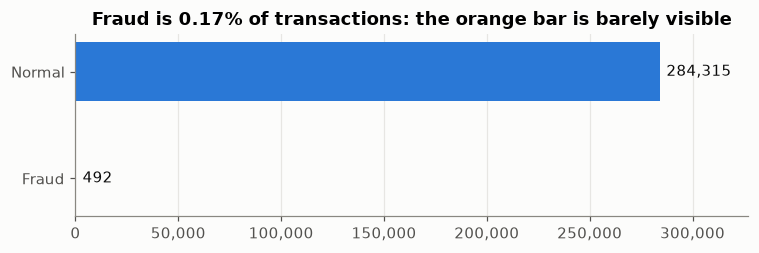

In [3]:
fig, ax = plt.subplots(figsize=(7, 2.4))
bars = ax.barh(["Fraud", "Normal"], [counts[1], counts[0]], color=[FRAUD, NORMAL], height=0.55)
for b, v in zip(bars, [counts[1], counts[0]]):
    ax.text(b.get_width() + 3000, b.get_y() + b.get_height() / 2, f"{v:,}", va="center", color="#0b0b0b")
ax.set_title("Fraud is 0.17% of transactions: the orange bar is barely visible")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_xlim(0, counts[0] * 1.15); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

In [4]:
amt = df.groupby("Class")["Amount"].describe()[["mean", "50%", "max"]].rename(index={0: "Normal", 1: "Fraud"})
amt["total"] = df.groupby("Class")["Amount"].sum().values
amt

,mean,50%,max,total
Class,,,,
Normal,88.2910,22.0000,"25,691.1600","25,102,462.0400"
Fraud,122.2113,9.2500,"2,125.8700","60,127.9700"


Fraud amounts are **smaller** than normal ones on average: the median fraud is about €9. That matters for the cost
model later. Chasing a €1 fraud with a €10 review loses money.

**Time:** `Time` counts seconds from the first transaction, over roughly 48 hours. I turn it into an hour of day,
assuming the data starts at midnight. The pattern supports this: volume collapses between about 1am and 6am.

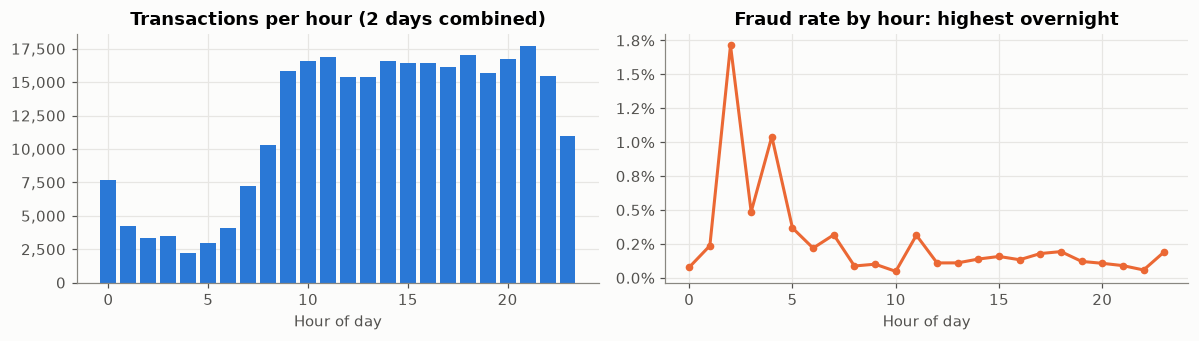

Peak fraud-rate hour: 2 (1.71%)


In [5]:
df["Hour"] = ((df["Time"] % 86400) // 3600).astype(int)
bins = [0, 1, 10, 50, 100, 500, 1000, np.inf]
labels = ["€0–1", "€1–10", "€10–50", "€50–100", "€100–500", "€500–1,000", "€1,000+"]
df["AmountBin"] = pd.cut(df["Amount"], bins=bins, labels=labels, right=False).astype(str)

by_hour = df.groupby("Hour").agg(transactions=("Class", "size"), frauds=("Class", "sum"))
by_hour["fraud_rate"] = by_hour["frauds"] / by_hour["transactions"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))
a1.bar(by_hour.index, by_hour["transactions"], color=NORMAL, width=0.8)
a1.set_title("Transactions per hour (2 days combined)"); a1.set_xlabel("Hour of day")
a1.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
a2.plot(by_hour.index, by_hour["fraud_rate"], color=FRAUD, marker="o", markersize=4)
a2.set_title("Fraud rate by hour: highest overnight"); a2.set_xlabel("Hour of day")
a2.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=1))
plt.tight_layout(); plt.show()
print("Peak fraud-rate hour:", by_hour["fraud_rate"].idxmax(), f"({by_hour['fraud_rate'].max():.2%})")

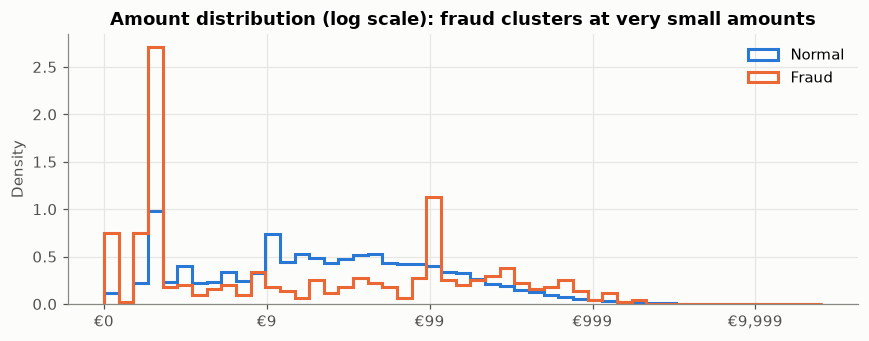

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.2))
b = np.linspace(0, np.log10(df["Amount"].max() + 1), 50)
for cls, color, name in [(0, NORMAL, "Normal"), (1, FRAUD, "Fraud")]:
    ax.hist(np.log10(df.loc[df.Class == cls, "Amount"] + 1), bins=b, density=True, histtype="step",
            color=color, linewidth=2, label=name)
ax.set_xticks([0, 1, 2, 3, 4]); ax.set_xticklabels(["€0", "€9", "€99", "€999", "€9,999"])
ax.set_title("Amount distribution (log scale): fraud clusters at very small amounts")
ax.set_ylabel("Density"); ax.legend(); plt.tight_layout(); plt.show()

In [7]:
corr = df[V_COLS + ["Amount", "Class"]].corr()["Class"].drop("Class").sort_values(key=np.abs, ascending=False)
print("Strongest single-feature links to fraud (correlation with Class):")
corr.head(8).to_frame("corr_with_fraud")

Strongest single-feature links to fraud (correlation with Class):


,corr_with_fraud
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549


## 2. Features and a 60 / 20 / 20 split

**Model features:** `V1`–`V28`, `LogAmount` (amounts are very skewed), and the hour written as two circle
coordinates (`HourSin`, `HourCos`) so the model knows 11pm and midnight are neighbours. Raw `Time` is dropped,
because "seconds since the file started" means nothing for next month's data.

**Split:** stratified, so every part keeps the 0.17% fraud rate.
- **Train (60%):** models learn here. SMOTE and undersampling only ever touch this part.
- **Validation (20%):** used to compare techniques and **pick the cutoff**.
- **Test (20%):** locked away, scored once at the very end.

In [8]:
df["LogAmount"] = np.log1p(df["Amount"])
df["HourSin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["HourCos"] = np.cos(2 * np.pi * df["Hour"] / 24)
FEATURES = V_COLS + ["LogAmount", "HourSin", "HourCos"]

train_idx, temp_idx = train_test_split(df.index, test_size=0.40, stratify=df["Class"], random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, stratify=df.loc[temp_idx, "Class"], random_state=SEED)
df["Split"] = "train"
df.loc[val_idx, "Split"] = "validation"
df.loc[test_idx, "Split"] = "test"

tr, va, te = (df[df.Split == s] for s in ("train", "validation", "test"))
X_tr, y_tr = tr[FEATURES], tr["Class"].to_numpy()
X_va, y_va = va[FEATURES], va["Class"].to_numpy()
X_te, y_te = te[FEATURES], te["Class"].to_numpy()

split_table = df.groupby("Split").agg(rows=("Class", "size"), frauds=("Class", "sum"), fraud_rate=("Class", "mean"))
assert not set(tr.TxnID) & set(te.TxnID) and not set(tr.TxnID) & set(va.TxnID) and not set(va.TxnID) & set(te.TxnID)
df[["TxnID", "Split"]].to_csv(PROCESSED / "splits.csv", index=False)
split_table.loc[["train", "validation", "test"]]

,rows,frauds,fraud_rate
Split,,,
train,170884,295,0.0017
validation,56961,98,0.0017
test,56962,99,0.0017


## 3. Why accuracy is useless here

A "model" that says **nothing is ever fraud** is 99.83% accurate and catches zero fraud. So from here on I judge
models by:
- **Precision:** of the transactions I flag, how many are really fraud? Low precision means lots of false alarms.
- **Recall:** of all the real fraud, how much did I catch? Low recall means missed fraud.
- **PR-AUC (average precision):** the precision/recall trade-off summed over every possible cutoff. It's the main
  score for comparing models. A random guess scores about 0.0017 here, and a perfect model scores 1.0.
- **ROC-AUC** is reported but not trusted. With so few frauds it looks great even for weak models.

In [9]:
def cost_at(y, flagged, amount):
    # Business cost: missed fraud costs its amount; every flagged transaction costs a review
    tp = flagged & (y == 1); fp = flagged & (y == 0); fn = ~flagged & (y == 1)
    caught, missed = amount[tp].sum(), amount[fn].sum()
    review = FP_COST * fp.sum() + TP_COST * tp.sum()
    return dict(TP=int(tp.sum()), FP=int(fp.sum()), FN=int(fn.sum()), TN=int((~flagged & (y == 0)).sum()),
                FraudCaughtEUR=caught, FraudMissedEUR=missed, ReviewCost=review, TotalCost=missed + review,
                NetSavings=amount[y == 1].sum() - (missed + review))

def evaluate(name, y, score, amount, threshold, stage, technique=""):
    flagged = score >= threshold
    c = cost_at(y, flagged, amount)
    p = c["TP"] / max(c["TP"] + c["FP"], 1); r = c["TP"] / max(c["TP"] + c["FN"], 1)
    return dict(Stage=stage, Model=name, Imbalance=technique, PR_AUC=average_precision_score(y, score),
                ROC_AUC=roc_auc_score(y, score), Accuracy=accuracy_score(y, flagged), Threshold=threshold,
                Precision=p, Recall=r, F1=0 if p + r == 0 else 2 * p * r / (p + r), **c)

amt_va, amt_te = va["Amount"].to_numpy(), te["Amount"].to_numpy()
always_normal = evaluate("Always 'not fraud'", y_va, np.zeros(len(y_va)), amt_va, 0.5, "validation")
pd.DataFrame([always_normal])[["Model", "Accuracy", "Precision", "Recall", "TP", "FN", "FraudMissedEUR"]]

,Model,Accuracy,Precision,Recall,TP,FN,FraudMissedEUR
0,Always 'not fraud',0.9983,0.0000,0.0000,0,98,"12,529.6000"


## 4. Handling the imbalance: four ways, same model

To see what each technique really does, I hold the model fixed (logistic regression) and change only how it
deals with the imbalance:

| Technique | What it does |
|---|---|
| No adjustment | Train on the data as-is |
| Class weights | Tell the model a missed fraud counts about 580× more than a missed normal |
| SMOTE | Invent synthetic fraud examples between real ones until the classes balance |
| Undersampling | Throw away normal transactions until the classes balance |

**Leakage guard:** SMOTE and undersampling sit *inside* an `imblearn` pipeline. They only run when the pipeline
is **fit**, which happens on training data. Validation and test are never resampled, so every score below is on
real, untouched transactions.

In [10]:
lr = lambda **kw: LogisticRegression(max_iter=3000, **kw)
imbalance_models = {
    "No adjustment": Pipeline([("scale", StandardScaler()), ("lr", lr())]),
    "Class weights": Pipeline([("scale", StandardScaler()), ("lr", lr(class_weight="balanced"))]),
    "SMOTE": ImbPipeline([("scale", StandardScaler()), ("smote", SMOTE(random_state=SEED)), ("lr", lr())]),
    "Undersampling": ImbPipeline([("scale", StandardScaler()), ("under", RandomUnderSampler(random_state=SEED)), ("lr", lr())]),
}
study, val_scores = [], {}
for tech, m in imbalance_models.items():
    m.fit(X_tr, y_tr)
    val_scores[tech] = m.predict_proba(X_va)[:, 1]
    study.append(evaluate("Logistic Regression", y_va, val_scores[tech], amt_va, 0.5, "validation: imbalance study", tech))
study_df = pd.DataFrame(study)
study_df[["Imbalance", "PR_AUC", "ROC_AUC", "Precision", "Recall", "F1", "TP", "FP", "FN"]]

,Imbalance,PR_AUC,ROC_AUC,Precision,Recall,F1,TP,FP,FN
0,No adjustment,0.6750,0.9691,0.7949,0.6327,0.7045,62,16,36
1,Class weights,0.6847,0.9807,0.0618,0.8776,0.1155,86,1305,12
2,SMOTE,0.6853,0.9790,0.0591,0.8980,0.1109,88,1401,10
3,Undersampling,0.6381,0.9750,0.0383,0.8776,0.0733,86,2162,12


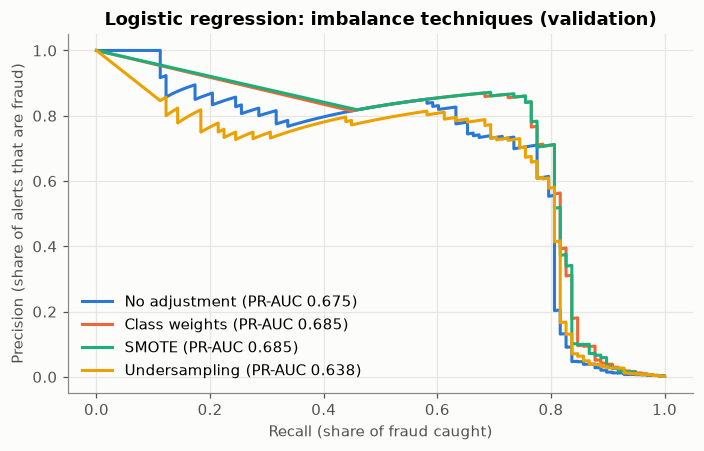

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for (tech, s), color in zip(val_scores.items(), MODEL_COLORS.values()):
    p, r, _ = precision_recall_curve(y_va, s)
    ax.plot(r, p, color=color, label=f"{tech} (PR-AUC {average_precision_score(y_va, s):.3f})")
ax.set_xlabel("Recall (share of fraud caught)"); ax.set_ylabel("Precision (share of alerts that are fraud)")
ax.set_title("Logistic regression: imbalance techniques (validation)")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()

**What this shows:** at the default 0.5 cutoff the techniques look completely different. "No adjustment" is cautious and
misses fraud. SMOTE and undersampling catch more fraud but raise a flood of false alarms. The **PR-AUC**, which
scores every cutoff at once, moves much less. Resampling mostly shifts *where* the model draws the line; it
doesn't make the model much better at telling fraud apart from normal. That's why the cutoff gets tuned
separately in section 6 instead of being left at 0.5.

For the final comparison I carry forward the logistic regression variant with the best validation PR-AUC.

In [12]:
best_lr_tech = study_df.sort_values("PR_AUC", ascending=False).iloc[0]["Imbalance"]
lr_model = imbalance_models[best_lr_tech]
print("Logistic regression carried forward:", best_lr_tech)

Logistic regression carried forward: SMOTE


## 5. Stronger models

- **Random Forest:** 300 trees with `class_weight="balanced_subsample"`, which re-weights fraud inside each tree's
  sample.
- **XGBoost:** boosted trees. Imbalance is handled with `scale_pos_weight`. I tune two settings with **5-fold
  stratified cross-validation on train only**, scored by PR-AUC: tree depth, and whether to use the full
  normal-to-fraud ratio (~580) or its square root (~24).
- **Isolation Forest:** unsupervised. It never sees the labels and just scores how *unusual* each transaction
  looks. This covers the case where a company has no fraud labels yet.

In [13]:
ratio = (y_tr == 0).sum() / (y_tr == 1).sum()
xgb = lambda **kw: XGBClassifier(n_estimators=400, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                 tree_method="hist", eval_metric="aucpr", n_jobs=-1, random_state=SEED, **kw)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid = []
for depth in (3, 5):
    for spw_name, spw in (("full ratio", ratio), ("sqrt ratio", np.sqrt(ratio))):
        s = cross_val_score(xgb(max_depth=depth, scale_pos_weight=spw), X_tr, y_tr, cv=cv, scoring="average_precision")
        grid.append(dict(max_depth=depth, scale_pos_weight=spw_name, spw_value=round(spw, 1), cv_pr_auc=s.mean(), cv_std=s.std()))
grid_df = pd.DataFrame(grid).sort_values("cv_pr_auc", ascending=False)
best = grid_df.iloc[0]
print(f"Normal:fraud ratio in train = {ratio:,.0f}:1")
grid_df

Normal:fraud ratio in train = 578:1


,max_depth,scale_pos_weight,spw_value,cv_pr_auc,cv_std
3,5,sqrt ratio,24.0000,0.8589,0.0371
2,5,full ratio,578.3000,0.8566,0.0356
1,3,sqrt ratio,24.0000,0.8526,0.0342
0,3,full ratio,578.3000,0.8371,0.0274


In [14]:
xgb_model = xgb(max_depth=int(best.max_depth), scale_pos_weight=float(best.spw_value)).fit(X_tr, y_tr)
rf_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight="balanced_subsample",
                                  n_jobs=-1, random_state=SEED).fit(X_tr, y_tr)
iso_model = IsolationForest(n_estimators=300, random_state=SEED, n_jobs=-1).fit(X_tr)   # no labels used

# Isolation Forest gives "weirdness", not a probability: rescale to 0-1 using the training range
iso_raw_tr = -iso_model.score_samples(X_tr)
iso_lo, iso_hi = iso_raw_tr.min(), iso_raw_tr.max()
iso_score = lambda X: np.clip((-iso_model.score_samples(X) - iso_lo) / (iso_hi - iso_lo), 0, 1)

MODELS = {"XGBoost": lambda X: xgb_model.predict_proba(X)[:, 1],
          "Random Forest": lambda X: rf_model.predict_proba(X)[:, 1],
          "Logistic Regression": lambda X: lr_model.predict_proba(X)[:, 1],
          "Isolation Forest": iso_score}
val_pred = {name: f(X_va) for name, f in MODELS.items()}
pd.DataFrame([dict(Model=n, PR_AUC=average_precision_score(y_va, s), ROC_AUC=roc_auc_score(y_va, s))
              for n, s in val_pred.items()]).sort_values("PR_AUC", ascending=False)

,Model,PR_AUC,ROC_AUC
0,XGBoost,0.8286,0.9837
1,Random Forest,0.8023,0.9542
2,Logistic Regression,0.6853,0.9790
3,Isolation Forest,0.1271,0.9461


## 6. Choosing the cutoff by cost (validation only)

Every model outputs a score, and a **cutoff** turns it into flag or don't flag. Think of it as a smoke alarm's
sensitivity dial. Set it too sensitive and it goes off every time you make toast (false alarms). Set it too dull
and it misses a real fire (missed fraud).

**Cost model:**
- A **missed fraud** costs its full amount.
- **Every flagged transaction** costs €10 to review, whether it turns out to be fraud or not.
- The €10 is an assumption. In Tableau it becomes a slider.

For each model I try every cutoff from 0.001 to 0.999 on **validation** and keep the cheapest. The test set still
hasn't been touched.

In [15]:
THRESHOLDS = np.round(np.arange(0.001, 1.0, 0.001), 3)

def curve(name, y, score, amount):
    rows = []
    for t in THRESHOLDS:
        c = cost_at(y, score >= t, amount)
        p = c["TP"] / max(c["TP"] + c["FP"], 1); r = c["TP"] / max(c["TP"] + c["FN"], 1)
        rows.append(dict(Model=name, Threshold=t, Precision=p, Recall=r, F1=0 if p + r == 0 else 2 * p * r / (p + r), **c))
    return pd.DataFrame(rows)

val_curves = pd.concat([curve(n, y_va, s, amt_va) for n, s in val_pred.items()], ignore_index=True)
chosen = val_curves.loc[val_curves.groupby("Model")["TotalCost"].idxmin(), ["Model", "Threshold", "TotalCost", "Precision", "Recall"]]
no_model_cost_va = amt_va[y_va == 1].sum()
chosen["SavingsVsNoModel"] = no_model_cost_va - chosen["TotalCost"]
THRESH = dict(zip(chosen.Model, chosen.Threshold))
print(f"Cost with no model on validation (every fraud slips through): EUR {no_model_cost_va:,.2f}")
chosen.sort_values("TotalCost")

Cost with no model on validation (every fraud slips through): EUR 12,529.60


,Model,Threshold,TotalCost,Precision,Recall,SavingsVsNoModel
261,XGBoost,0.2620,"5,187.1800",0.8864,0.7959,"7,342.4200"
1275,Random Forest,0.2770,"5,217.1800",0.8571,0.7959,"7,312.4200"
2996,Logistic Regression,0.9990,"5,445.1800",0.6930,0.8061,"7,084.4200"
3674,Isolation Forest,0.6780,"10,357.5500",0.1867,0.2857,"2,172.0500"


**Two things to notice:**
- XGBoost, Random Forest and logistic regression all land within a few hundred euros of each other on cost. The
  cutoff matters as much as the model.
- Logistic regression's cheapest cutoff is **0.999**, the very top of the range. The SMOTE training taught it that
  fraud is common, so it hands out very high scores to lots of normal transactions. Resampling changes what the
  scores *mean*, which is why a score from a resampled model should never be read as a real probability.

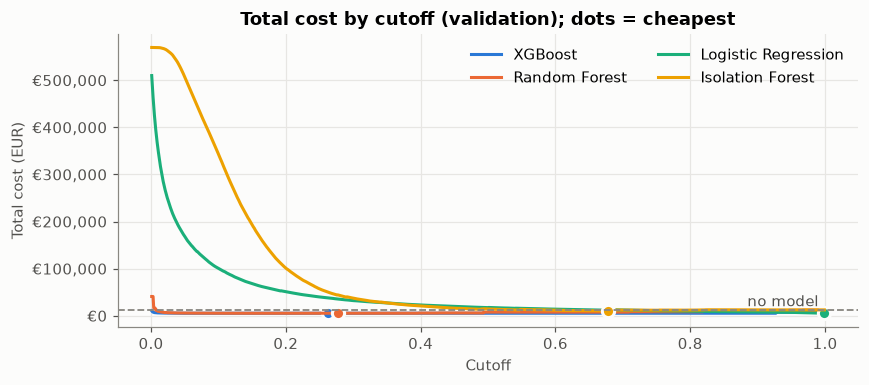

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for name, color in MODEL_COLORS.items():
    d = val_curves[val_curves.Model == name]
    ax.plot(d.Threshold, d.TotalCost, color=color, label=name)
    ax.plot(THRESH[name], d.TotalCost.min(), "o", color=color, markersize=8, markeredgecolor="#fcfcfb", markeredgewidth=2)
ax.axhline(no_model_cost_va, color="#898781", linestyle="--", linewidth=1.2)
ax.text(0.99, no_model_cost_va, " no model", color="#52514e", va="bottom", ha="right")
ax.set_xlabel("Cutoff"); ax.set_ylabel("Total cost (EUR)"); ax.set_title("Total cost by cutoff (validation); dots = cheapest")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("€{x:,.0f}")); ax.legend(ncol=2)
plt.tight_layout(); plt.show()

## 7. Final exam: score the test set once

Every model is now scored on the 20% test set it has never seen, **using the cutoff it picked on validation**.
These are the numbers I report.

In [17]:
test_pred = {name: f(X_te) for name, f in MODELS.items()}
final = pd.DataFrame([evaluate(n, y_te, s, amt_te, THRESH[n], "test", "") for n, s in test_pred.items()])
final["Imbalance"] = final["Model"].map({"XGBoost": f"scale_pos_weight ({best.scale_pos_weight})",
                                         "Random Forest": "balanced_subsample weights",
                                         "Logistic Regression": best_lr_tech, "Isolation Forest": "unsupervised"})
final = final.sort_values("PR_AUC", ascending=False)
WINNER = final.iloc[0]["Model"]
no_model_cost_te = amt_te[y_te == 1].sum()
print(f"Winner by test PR-AUC: {WINNER}.  Test set: {len(y_te):,} transactions, {y_te.sum()} frauds, "
      f"EUR {no_model_cost_te:,.2f} of fraud")
final[["Model", "PR_AUC", "ROC_AUC", "Threshold", "Precision", "Recall", "F1", "TP", "FP", "FN",
       "FraudCaughtEUR", "FraudMissedEUR", "ReviewCost", "NetSavings"]]

Winner by test PR-AUC: XGBoost.  Test set: 56,962 transactions, 99 frauds, EUR 9,874.35 of fraud


,Model,PR_AUC,ROC_AUC,Threshold,Precision,Recall,F1,TP,FP,FN,FraudCaughtEUR,FraudMissedEUR,ReviewCost,NetSavings
0,XGBoost,0.8782,0.9778,0.2620,0.8936,0.8485,0.8705,84,10,15,"7,366.3800","2,507.9700",940.0000,"6,426.3800"
1,Random Forest,0.8766,0.9561,0.2770,0.8901,0.8182,0.8526,81,10,18,"7,156.2900","2,718.0600",910.0000,"6,246.2900"
2,Logistic Regression,0.7656,0.9668,0.9990,0.7345,0.8384,0.7830,83,30,16,"7,366.6000","2,507.7500","1,130.0000","6,236.6000"
3,Isolation Forest,0.1470,0.9528,0.6780,0.1678,0.2424,0.1983,24,119,75,"3,997.2900","5,877.0600","1,430.0000","2,567.2900"


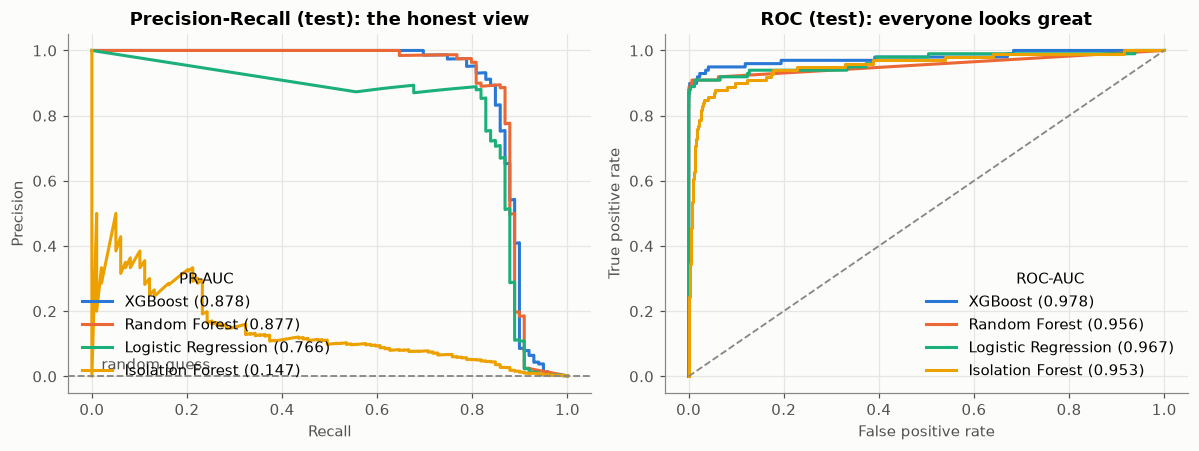

In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
for name, color in MODEL_COLORS.items():
    p, r, _ = precision_recall_curve(y_te, test_pred[name])
    a1.plot(r, p, color=color, label=f"{name} ({average_precision_score(y_te, test_pred[name]):.3f})")
    fpr, tpr, _ = roc_curve(y_te, test_pred[name])
    a2.plot(fpr, tpr, color=color, label=f"{name} ({roc_auc_score(y_te, test_pred[name]):.3f})")
a1.axhline(y_te.mean(), color="#898781", linestyle="--", linewidth=1.2); a1.text(0.02, y_te.mean() + 0.02, "random guess", color="#52514e")
a1.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall (test): the honest view")
a2.plot([0, 1], [0, 1], color="#898781", linestyle="--", linewidth=1.2)
a2.set(xlabel="False positive rate", ylabel="True positive rate", title="ROC (test): everyone looks great")
a1.legend(loc="lower left", title="PR-AUC"); a2.legend(loc="lower right", title="ROC-AUC")
plt.tight_layout(); plt.show()

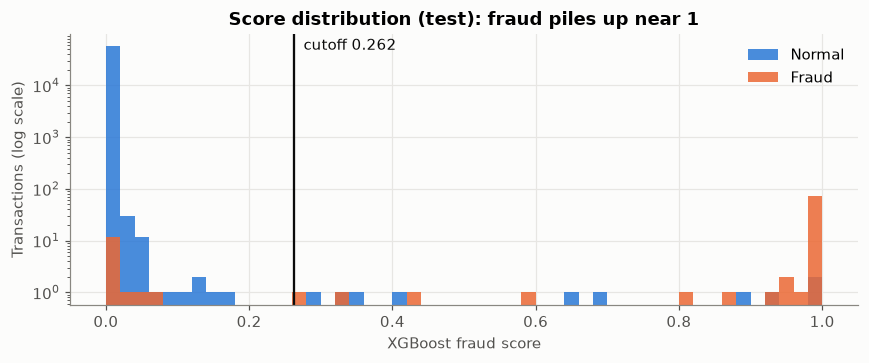

,Not flagged,Flagged
Actually normal,56853,10
Actually fraud,15,84


In [19]:
w = test_pred[WINNER]
fig, ax = plt.subplots(figsize=(8, 3.4))
b = np.linspace(0, 1, 51)
ax.hist(w[y_te == 0], bins=b, color=NORMAL, alpha=0.85, label="Normal", log=True)
ax.hist(w[y_te == 1], bins=b, color=FRAUD, alpha=0.85, label="Fraud", log=True)
ax.axvline(THRESH[WINNER], color="#0b0b0b", linewidth=1.5)
ax.text(THRESH[WINNER], ax.get_ylim()[1] * 0.5, f"  cutoff {THRESH[WINNER]:.3f}", color="#0b0b0b")
ax.set(xlabel=f"{WINNER} fraud score", ylabel="Transactions (log scale)", title="Score distribution (test): fraud piles up near 1")
ax.legend(); plt.tight_layout(); plt.show()
cm = confusion_matrix(y_te, w >= THRESH[WINNER])
pd.DataFrame(cm, index=["Actually normal", "Actually fraud"], columns=["Not flagged", "Flagged"])

## 8. Why did it flag that? (SHAP)

SHAP splits each prediction into **how much each feature pushed it toward fraud or away from it**. I group the
two hour columns back into `Hour` and show `LogAmount` as `Amount`, so the drivers read naturally. The V-features
are anonymised, so the explanation can say *"V14 was unusually low"* but not what V14 means in the real world.
That's a limit of this public dataset, not of the method.

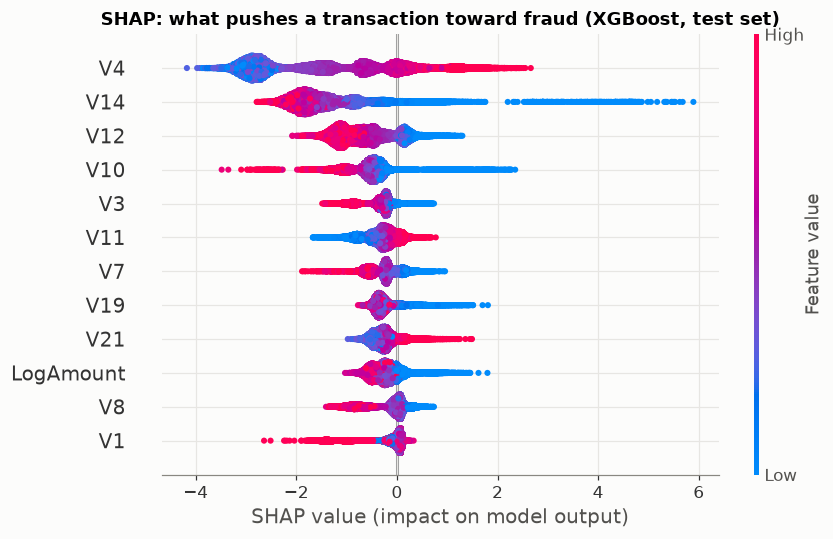

,MeanAbsSHAP,XGB_GainShare,Rank
V4,1.7042,0.0415,1
V14,1.4753,0.4426,2
V12,0.7107,0.0378,3
V10,0.6004,0.1466,4
V3,0.3715,0.0092,5
V11,0.3409,0.0165,6
V7,0.3137,0.0140,7
V19,0.3134,0.0132,8
V21,0.3020,0.0123,9
Amount,0.2942,0.0169,10


In [20]:
explainer = shap.TreeExplainer(xgb_model)
sv = explainer.shap_values(X_te)
sv_df = pd.DataFrame(sv, columns=FEATURES, index=te.index)
sv_df["Hour"] = sv_df.pop("HourSin") + sv_df.pop("HourCos")
sv_df = sv_df.rename(columns={"LogAmount": "Amount"})

gain = pd.Series(xgb_model.get_booster().get_score(importance_type="gain"))
gain = gain.rename({"LogAmount": "Amount"})
gain["Hour"] = gain.pop("HourSin") if "HourSin" in gain else 0
gain["Hour"] += gain.pop("HourCos") if "HourCos" in gain else 0
importance = (sv_df.abs().mean().rename("MeanAbsSHAP").to_frame()
              .join((gain / gain.sum()).rename("XGB_GainShare")).fillna(0)
              .sort_values("MeanAbsSHAP", ascending=False))
importance["Rank"] = np.arange(1, len(importance) + 1)

shap.summary_plot(sv, X_te, feature_names=FEATURES, max_display=12, show=False, plot_size=(8, 5))
plt.title("SHAP: what pushes a transaction toward fraud (XGBoost, test set)"); plt.tight_layout(); plt.show()
importance.head(10)

In [21]:
# Top 3 drivers per transaction: the features that pushed its score UP the most
vals = sv_df.to_numpy(); names = np.array(sv_df.columns)
order = np.argsort(-vals, axis=1)[:, :3]
drivers = pd.DataFrame(index=te.index)
for k in range(3):
    drivers[f"Driver{k + 1}"] = names[order[:, k]]
    drivers[f"Driver{k + 1}_Impact"] = vals[np.arange(len(vals)), order[:, k]]
drivers.join(te[["Class"]]).assign(Score=test_pred[WINNER]).sort_values("Score", ascending=False).head(8)

,Driver1,Driver1_Impact,Driver2,Driver2_Impact,Driver3,Driver3_Impact,Class,Score
42769,V14,4.7354,V10,1.9269,V4,1.6329,1,0.9999
150663,V14,4.6204,V10,1.8296,V4,1.8005,1,0.9999
153823,V14,3.9064,V10,1.7979,V4,1.7210,1,0.9999
204064,V14,4.3088,V10,2.0138,V17,1.5623,1,0.9999
43204,V14,4.6960,V10,1.8301,V4,1.6575,1,0.9999
42756,V14,4.6711,V10,1.8135,V4,1.7583,1,0.9999
150677,V14,4.4659,V10,1.7737,V4,1.6577,1,0.9999
42009,V14,4.7352,V10,1.8103,V4,1.7703,1,0.9999


## 9. Export for Tableau

| File | One row per | Feeds |
|---|---|---|
| `scored_transactions.csv` | test transaction | live threshold calculations, score distribution, alert queue |
| `threshold_curve.csv` | model × cutoff (test) | PR curve, cost-vs-cutoff curve |
| `roc_curve.csv` | model × ROC point (test) | ROC curve |
| `model_comparison.csv` | model / technique / stage | leaderboard, imbalance study |
| `feature_importance.csv` | feature | risk drivers |
| `class_summary.csv` | class × hour × amount bin (all 284,807 rows) | imbalance overview |

In [22]:
TOP_V = [f for f in importance.index if f.startswith("V")][:5]
scored = te[["TxnID", "Class", "Amount", "Hour", "AmountBin"] + TOP_V].rename(columns={"Class": "TrueLabel"}).copy()
scored["TrueLabelName"] = np.where(scored.TrueLabel == 1, "Fraud", "Normal")
scored["XGB_Prob"] = test_pred["XGBoost"]
scored["RF_Prob"] = test_pred["Random Forest"]
scored["LR_Prob"] = test_pred["Logistic Regression"]
scored["IForest_Score"] = test_pred["Isolation Forest"]
scored = scored.join(drivers)
scored = scored.sort_values("XGB_Prob", ascending=False)
# Full precision on purpose: SMOTE pushes many logistic-regression scores to 0.9999..., and rounding creates ties
scored.to_csv(TABLEAU / "scored_transactions.csv", index=False)

test_curves = pd.concat([curve(n, y_te, s, amt_te) for n, s in test_pred.items()], ignore_index=True)
test_curves["IsChosenThreshold"] = test_curves.apply(lambda r: r.Threshold == THRESH[r.Model], axis=1)
test_curves.round(6).to_csv(TABLEAU / "threshold_curve.csv", index=False)

roc_rows = []
for n, s in test_pred.items():
    fpr, tpr, thr = roc_curve(y_te, s)
    roc_rows.append(pd.DataFrame(dict(Model=n, FPR=fpr, TPR=tpr, Threshold=np.clip(thr, 0, 1))))
pd.concat(roc_rows, ignore_index=True).round(6).to_csv(TABLEAU / "roc_curve.csv", index=False)

val_final = pd.DataFrame([evaluate(n, y_va, s, amt_va, THRESH[n], "validation") for n, s in val_pred.items()])
val_final["Imbalance"] = val_final["Model"].map(final.set_index("Model")["Imbalance"])
comparison = pd.concat([study_df, val_final, final], ignore_index=True)
comparison.round(6).to_csv(TABLEAU / "model_comparison.csv", index=False)

desc = {f: "Anonymised PCA component" for f in V_COLS} | {"Amount": "Transaction amount (log EUR)", "Hour": "Hour of day"}
importance.rename_axis("Feature").reset_index().assign(Description=lambda d: d.Feature.map(desc)) \
    .round(6).to_csv(TABLEAU / "feature_importance.csv", index=False)

(df.assign(ClassName=np.where(df.Class == 1, "Fraud", "Normal"))
   .groupby(["ClassName", "Hour", "AmountBin"], as_index=False)
   .agg(Transactions=("TxnID", "size"), TotalAmount=("Amount", "sum"))
   .round(2).to_csv(TABLEAU / "class_summary.csv", index=False))

metrics = dict(
    rows=len(df), frauds=int(df.Class.sum()), fraud_rate=float(df.Class.mean()),
    duplicates=int(dups), split=split_table.reset_index().to_dict("records"),
    features=FEATURES, xgb_params=dict(max_depth=int(best.max_depth), scale_pos_weight=float(best.spw_value)),
    xgb_cv_grid=grid_df.to_dict("records"), best_lr_technique=best_lr_tech, winner=WINNER,
    thresholds=THRESH, fp_cost=FP_COST, tp_cost=TP_COST,
    no_model_cost_validation=float(no_model_cost_va), no_model_cost_test=float(no_model_cost_te),
    peak_fraud_hour=int(by_hour["fraud_rate"].idxmax()),
    test=final.to_dict("records"), imbalance_study=study_df.to_dict("records"),
    top_features=importance.head(10).reset_index(names="Feature")[["Feature", "MeanAbsSHAP"]].to_dict("records"))
(PROCESSED / "metrics.json").write_text(json.dumps(metrics, indent=2, default=float))
for f in sorted(TABLEAU.glob("*.csv")):
    print(f"{f.name:28s} {sum(1 for _ in open(f, encoding='utf-8')) - 1:>8,} rows")

class_summary.csv                 293 rows
feature_importance.csv             30 rows
model_comparison.csv               12 rows
roc_curve.csv                   2,714 rows
scored_transactions.csv        56,962 rows
threshold_curve.csv             3,996 rows


## 10. Summary

The printout below is generated from the results. The written recommendations are in `README.md`.

In [23]:
w = final.set_index("Model").loc[WINNER]
print(f"Winner: {WINNER}  (test PR-AUC {w.PR_AUC:.3f}; cutoff {w.Threshold:.3f}, chosen on validation)")
print(f"  Caught {w.TP} of {w.TP + w.FN} frauds (recall {w.Recall:.1%}); {w.FP} false alarms (precision {w.Precision:.1%})")
print(f"  Fraud caught EUR {w.FraudCaughtEUR:,.2f} | missed EUR {w.FraudMissedEUR:,.2f} | review cost EUR {w.ReviewCost:,.2f}")
print(f"  Net savings vs no model: EUR {w.NetSavings:,.2f} of EUR {no_model_cost_te:,.2f} at risk "
      f"({w.NetSavings / no_model_cost_te:.1%})")
print(f"Imbalance study: best logistic-regression technique by PR-AUC = {best_lr_tech}")

Winner: XGBoost  (test PR-AUC 0.878; cutoff 0.262, chosen on validation)
  Caught 84 of 99 frauds (recall 84.8%); 10 false alarms (precision 89.4%)
  Fraud caught EUR 7,366.38 | missed EUR 2,507.97 | review cost EUR 940.00
  Net savings vs no model: EUR 6,426.38 of EUR 9,874.35 at risk (65.1%)
Imbalance study: best logistic-regression technique by PR-AUC = SMOTE
